# Customer Transaction Prediction Project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')

## 1. Let's check the data

In [2]:
train_df.shape, test_df.shape

((200000, 202), (200000, 201))

In [3]:
train_df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [4]:
test_df.head()

,ID_code,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,test_0,11.0656,7.7798,12.9536,9.4292,11.4327,-2.3805,5.8493,18.2675,2.1337,...,-2.1556,11.8495,-1.4300,2.4508,13.7112,2.4669,4.3654,10.7200,15.4722,-8.7197
1,test_1,8.5304,1.2543,11.3047,5.1858,9.1974,-4.0117,6.0196,18.6316,-4.4131,...,10.6165,8.8349,0.9403,10.1282,15.5765,0.4773,-1.4852,9.8714,19.1293,-20.9760
2,test_2,5.4827,-10.3581,10.1407,7.0479,10.2628,9.8052,4.8950,20.2537,1.5233,...,-0.7484,10.9935,1.9803,2.1800,12.9813,2.1281,-7.1086,7.0618,19.8956,-23.1794
3,test_3,8.5374,-1.3222,12.0220,6.5749,8.8458,3.1744,4.9397,20.5660,3.3755,...,9.5702,9.0766,1.6580,3.5813,15.1874,3.1656,3.9567,9.2295,13.0168,-4.2108
4,test_4,11.7058,-0.1327,14.1295,7.7506,9.1035,-8.5848,6.8595,10.6048,2.9890,...,4.2259,9.1723,1.2835,3.3778,19.5542,-0.2860,-5.1612,7.2882,13.9260,-9.1846


In [5]:
print(train_df.isnull().sum())

ID_code    0
target     0
var_0      0
var_1      0
var_2      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 202, dtype: int64


In [6]:
print(test_df.isnull().sum())

ID_code    0
var_0      0
var_1      0
var_2      0
var_3      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 201, dtype: int64


### It is fair to deduce that there are no missing values for the training and testing dataset which is rare but appreciated!

In [7]:
train_df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [8]:
test_df.describe()

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,10.658737,-1.624244,10.707452,6.788214,11.076399,-5.050558,5.415164,16.529143,0.277135,7.569407,...,3.189766,7.458269,1.925944,3.322016,17.996967,-0.133657,2.290899,8.912428,15.869184,-3.246342
std,3.036716,4.040509,2.633888,2.052724,1.616456,7.869293,0.864686,3.424482,3.333375,1.231865,...,4.551239,3.025189,1.479966,3.995599,3.140652,1.429678,5.446346,0.920904,3.008717,10.398589
min,0.188700,-15.043400,2.355200,-0.022400,5.484400,-27.767000,2.216400,5.713700,-9.956000,4.243300,...,-14.093300,-2.407000,-3.340900,-11.413100,9.382800,-4.911900,-13.944200,6.169600,6.584000,-39.457800
25%,8.442975,-4.700125,8.735600,5.230500,9.891075,-11.201400,4.772600,13.933900,-2.303900,6.623800,...,-0.095000,5.166500,0.882975,0.587600,15.634775,-1.160700,-1.948600,8.260075,13.847275,-11.124000
50%,10.513800,-1.590500,10.560700,6.822350,11.099750,-4.834100,5.391600,16.422700,0.372000,7.632000,...,3.162400,7.379000,1.892600,3.428500,17.977600,-0.162000,2.403600,8.892800,15.943400,-2.725950
75%,12.739600,1.343400,12.495025,8.327600,12.253400,0.942575,6.005800,19.094550,2.930025,8.584825,...,6.336475,9.531100,2.956000,6.174200,20.391725,0.837900,6.519800,9.595900,18.045200,4.935400
max,22.323400,9.385100,18.714100,13.142000,16.037100,17.253700,8.302500,28.292800,9.665500,11.003600,...,20.359000,16.716500,8.005000,17.632600,27.947800,4.545400,15.920700,12.275800,26.538400,27.907400


We can make few observations here:
The standard deviation is relatively large for both train and test variable data;
min, max, mean, std values for train and test data looks quite close;
mean values are distributed over a large range. 
I also checked for classes that had different scales

/var/folders/ph/vyb583kx0qq_33ttnfvfdrl80000gn/T/ipykernel_28899/34960797.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df[features].mean(axis=1),color="green", kde=True,bins=120, label='train')
/var/folders/ph/vyb583kx0qq_33ttnfvfdrl80000gn/T/ipykernel_28899/34960797.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed297

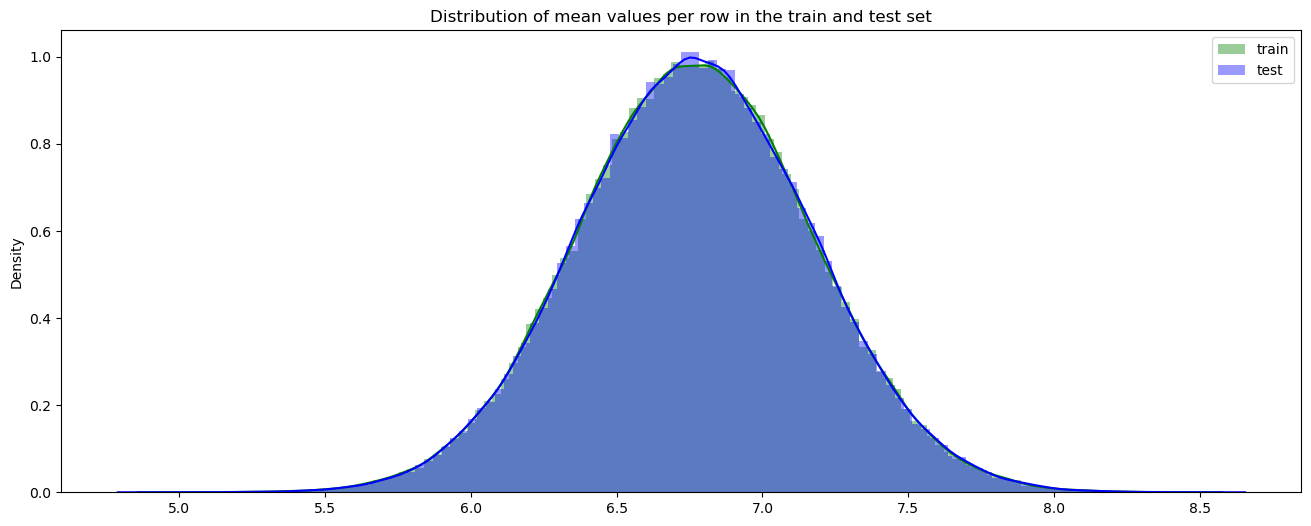

In [9]:
plt.figure(figsize=(16,6))
features = train_df.columns.values[2:202]
plt.title("Distribution of mean values per row in the train and test set")
sns.distplot(train_df[features].mean(axis=1),color="green", kde=True,bins=120, label='train')
sns.distplot(test_df[features].mean(axis=1),color="blue", kde=True,bins=120, label='test')
plt.legend()
plt.show()

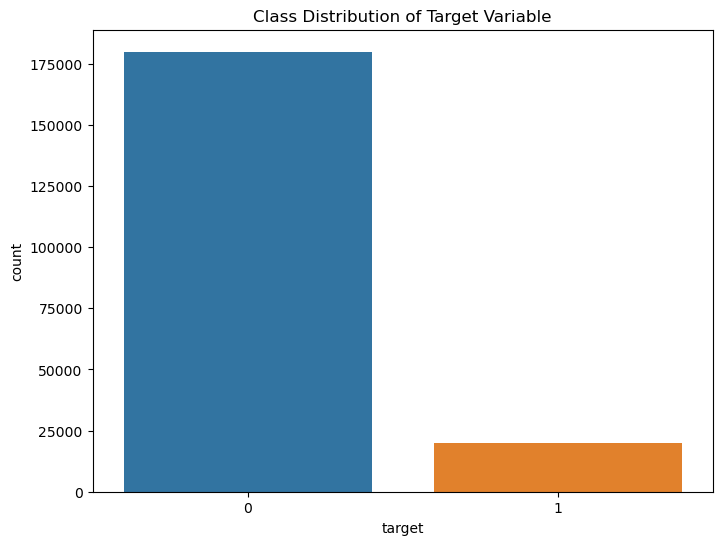

target
0    89.951
1    10.049
Name: proportion, dtype: float64


In [10]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=train_df)
plt.title('Class Distribution of Target Variable')
plt.show()

# Calculate the percentage of each class
class_proportions = train_df['target'].value_counts(normalize=True) * 100
print(class_proportions)


Here we now see that there is a stark difference in the class distribution between 0 and 1. This can lead to heavy bias in the model. Therefore, we can use Synthetic Minority Oversampling Technique (SMOTE) to balance the class distribution. In this process, we will essentially oversample the minority class while undersampling the majority class or XGBoost can use class weights. Then we will assign higher weights to the minroity class to make the model pay more attention to it.

# Now, let's build a machine learning model to predict the target variable.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

X = train_df.drop(['ID_code', 'target'], axis=1)  # Drop 'ID_code' as it's not useful for training
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Further Split X_train and y_train into Training and Validation Sets
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_split, y_train_split)

y_val_pred = gb_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.9026875
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     28794
           1       0.82      0.04      0.07      3206

    accuracy                           0.90     32000
   macro avg       0.86      0.52      0.51     32000
weighted avg       0.89      0.90      0.86     32000



The recall score for class label 1 is incredibly low. This is because the model is not able to distinguish between the classes correctly. The accurace score is very misleading given the the imbalanced class distribution. Hence why the presence of the f1-score is neccesary, so we can see that there isn't a good balance between precision and recall for the minority class. We should explore a model that can help to balance the class distribution of the minority class such as XGBoost. I could have also use SMOTE or SMOTE-ENN but they are not as effective as XGBoost.

Therefore I'm going to instead us XGBoost, which is much better with handling imbalanced data due  the specific features in space to address class imbalance.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [16]:
train_df = train_df.drop(columns=['ID_code'])
X = train_df.drop('target', axis=1)
y = train_df['target']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

class_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    scale_pos_weight=class_weight,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_test_pred = xgb_model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("Validation Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Validation Accuracy: 0.8258
              precision    recall  f1-score   support

           0       0.96      0.84      0.90     35980
           1       0.32      0.68      0.44      4020

    accuracy                           0.83     40000
   macro avg       0.64      0.76      0.67     40000
weighted avg       0.90      0.83      0.85     40000



Here we see that the overall accuaracy went down but the f1-score for class 1 was increased. This is expected because the model is now more sensitive to class 1. Now we can work to optimize the recall/f1 score.

## Let's try to optimize for Recall/F1-Score

In [18]:
y_test_probs = xgb_model.predict_proba(X_test)[:, 1]

# Adjust the threshold (e.g., 0.3 instead of 0.5)
from sklearn.metrics import precision_recall_curve

threshold = 0.6
y_test_pred_adjusted = (y_test_probs >= threshold).astype(int)

# Evaluate with the adjusted threshold
print("Adjusted Threshold Metrics")
print(classification_report(y_test, y_test_pred_adjusted))


Adjusted Threshold Metrics
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     35980
           1       0.47      0.47      0.47      4020

    accuracy                           0.89     40000
   macro avg       0.70      0.71      0.70     40000
weighted avg       0.89      0.89      0.89     40000



This model, with the adjusted threshold, provides a good trade-off between precision and recall for both classes. It’s likely the best fit for this imbalanced dataset, balancing detection of the minority class (class 1) without significantly compromising the majority class.

In [19]:
print("Test set size:", len(X_test))
print("Test labels size:", len(y_test))
print("Predicted probabilities size:", len(y_test_probs))

Test set size: 40000
Test labels size: 40000
Predicted probabilities size: 40000


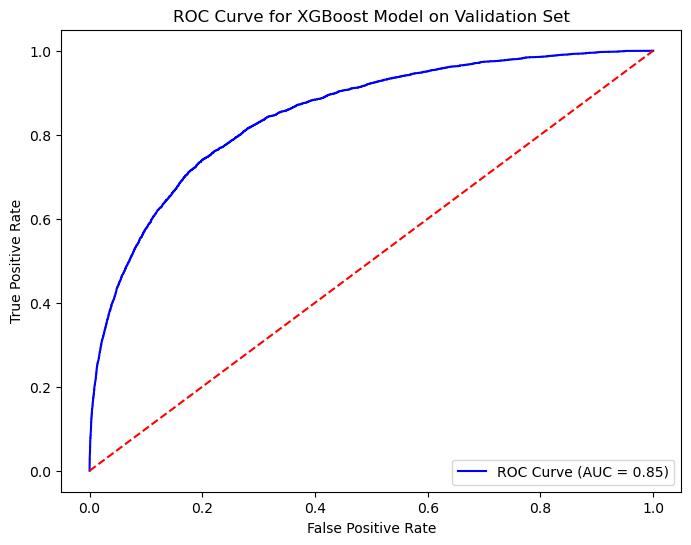

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = roc_auc_score(y_test, y_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost Model on Validation Set')
plt.legend(loc='lower right')
plt.show()


The closer the ROC curve is to the top-left corner, the better the model’s performance. Here, the curve is closer to the top-left, showing that the model has a good balance between the true positive rate and false positive rate. This shows us that the model performs well in distinguishing between the classes in the validation set, especially given the class imbalance in your data.

In [ ]:
X_test = test_df.drop('ID_code', axis=1, errors='ignore')  # Adjust if needed

# Predict probabilities on test set and apply the adjusted threshold
y_test_probs = xgb_model.predict_proba(X_test)[:, 1]
y_test_pred_adjusted = (y_test_probs >= threshold).astype(int)

# Print test predictions
print("Test Predictions with Adjusted Threshold:")
print(y_test_pred_adjusted)


We were able to acheive a 89% accuracy on the test set by using the adjusted threshold. Which is slightly lower than our 90% accuracy using the gradient boosting model but with a higher precision and recall for the minority class.